# Previsão de Prêmio de Seguro Escrito — Book de Agências (Insurance Agency Performance)

**Objetivo:** prever `WRTN_PREM_AMT` (o valor de prêmio escrito por uma agência, num produto,
num estado, num ano) a partir de dados de performance da agência — apólices em vigor, retenção,
sinistralidade, cotações e características cadastrais. Diferente dos outros projetos de
regressão do portfólio (Precificação Dinâmica, Elasticidade), aqui a unidade de análise não é
"uma corrida" ou "um produto numa semana" — é **agência × produto × estado × ano**.

**Dataset:** book de performance de agências de seguro (EUA, linhas Commercial Lines e Personal
Lines), 213.328 linhas, 49 colunas, cobrindo os anos de 2005 a 2015 em 6 estados.

## 1. Importação e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('finalapi.csv')
data.head()

,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_ABBR,PROD_LINE,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,...,PL_BOUND_CT_ELINKS,PL_QUO_CT_ELINKS,PL_BOUND_CT_PLRANK,PL_QUO_CT_PLRANK,PL_BOUND_CT_eQTte,PL_QUO_CT_eQTte,PL_BOUND_CT_APPLIED,PL_QUO_CT_APPLIED,PL_BOUND_CT_TRANSACTNOW,PL_QUO_CT_TRANSACTNOW
0,3,3,BOILERMACH,CL,IN,2005,0,0,0,40.0,...,0,0,0,103,50,288,0,0,0,0
1,3,3,BOILERMACH,CL,IN,2006,0,0,0,151.0,...,0,0,0,103,50,288,0,0,0,0
2,3,3,BOILERMACH,CL,IN,2007,0,0,0,40.0,...,0,0,0,103,50,288,0,0,0,0
3,3,3,BOILERMACH,CL,IN,2008,0,0,0,69.0,...,0,0,0,103,50,288,0,0,0,0
4,3,3,BOILERMACH,CL,IN,2009,0,0,0,28.0,...,0,0,0,103,50,288,0,0,0,0


## 2. Visão geral do dataset

In [2]:
print(data.shape)
data.info()

(213328, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213328 entries, 0 to 213327
Data columns (total 49 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   AGENCY_ID                  213328 non-null  int64  
 1   PRIMARY_AGENCY_ID          213328 non-null  int64  
 2   PROD_ABBR                  213328 non-null  object 
 3   PROD_LINE                  213328 non-null  object 
 4   STATE_ABBR                 213328 non-null  object 
 5   STAT_PROFILE_DATE_YEAR     213328 non-null  int64  
 6   RETENTION_POLY_QTY         213328 non-null  int64  
 7   POLY_INFORCE_QTY           213328 non-null  int64  
 8   PREV_POLY_INFORCE_QTY      213328 non-null  int64  
 9   NB_WRTN_PREM_AMT           213328 non-null  float64
 10  WRTN_PREM_AMT              213328 non-null  float64
 11  PREV_WRTN_PREM_AMT         213328 non-null  float64
 12  PRD_ERND_PREM_AMT          213328 non-null  float64
 13  PRD_INCRD_LOSSES

In [3]:
print("PROD_LINE:\n", data['PROD_LINE'].value_counts(), "\n")
print("STATE_ABBR:\n", data['STATE_ABBR'].value_counts(), "\n")
print("Anos:", data['STAT_PROFILE_DATE_YEAR'].min(), "a", data['STAT_PROFILE_DATE_YEAR'].max())
print("Produtos distintos (PROD_ABBR):", data['PROD_ABBR'].nunique())

PROD_LINE:
 PROD_LINE
CL    124692
PL     88636
Name: count, dtype: int64 

STATE_ABBR:
 STATE_ABBR
OH    101323
IN     34923
PA     32207
KY     29420
WV     11764
MI      3691
Name: count, dtype: int64 

Anos: 2005 a 2015
Produtos distintos (PROD_ABBR): 28


## 3. Achado: valores sentinela (99999) espalhados pelo dataset

Olhando o `describe()` das colunas numéricas, várias têm `max = 99999` — um valor claramente
fora de escala pra idade, ano ou razão. É o mesmo padrão de "código de sistema pra não
aplicável" que apareceu no projeto de Risco de Crédito (sentinela 96/98). Antes de tratar
qualquer coisa, vale mapear **quais colunas** usam esse código e **quanto** delas é sentinela.

In [4]:
sentinel_cols = ['MAX_AGE','MIN_AGE','AGENCY_APPOINTMENT_YEAR','ACTIVE_PRODUCERS',
                  'PL_START_YEAR','PL_END_YEAR','COMMISIONS_START_YEAR','COMMISIONS_END_YEAR',
                  'CL_START_YEAR','CL_END_YEAR','ACTIVITY_NOTES_START_YEAR','ACTIVITY_NOTES_END_YEAR',
                  'LOSS_RATIO','LOSS_RATIO_3YR','GROWTH_RATE_3YR','RETENTION_RATIO']

for c in sentinel_cols:
    pct = (data[c] == 99999).mean()
    print(f"{c:28s} {pct:6.1%} sentinela (99999)")

MAX_AGE                        2.6% sentinela (99999)
MIN_AGE                        2.6% sentinela (99999)
AGENCY_APPOINTMENT_YEAR        2.6% sentinela (99999)
ACTIVE_PRODUCERS               2.6% sentinela (99999)
PL_START_YEAR                 38.5% sentinela (99999)
PL_END_YEAR                   98.1% sentinela (99999)
COMMISIONS_START_YEAR         66.5% sentinela (99999)
COMMISIONS_END_YEAR           96.4% sentinela (99999)
CL_START_YEAR                 60.6% sentinela (99999)
CL_END_YEAR                   96.0% sentinela (99999)
ACTIVITY_NOTES_START_YEAR     80.4% sentinela (99999)
ACTIVITY_NOTES_END_YEAR       98.1% sentinela (99999)
LOSS_RATIO                    24.0% sentinela (99999)
LOSS_RATIO_3YR                23.0% sentinela (99999)
GROWTH_RATE_3YR               42.7% sentinela (99999)
RETENTION_RATIO               60.9% sentinela (99999)


**Leitura do achado:** o padrão não é uniforme. Colunas de idade/perfil (`MAX_AGE`, `MIN_AGE`,
`AGENCY_APPOINTMENT_YEAR`, `ACTIVE_PRODUCERS`) têm só 2,6% de sentinela — baixo impacto. Já as
colunas de data administrativa (`*_START_YEAR`/`*_END_YEAR` de apólice, comissão e notas de
atividade) chegam a **98% de sentinela** — na prática, são colunas quase vazias, provavelmente
processos que só passaram a ser registrados a partir de um certo sistema/ano. `RETENTION_RATIO`
(60,9%) e `GROWTH_RATE_3YR` (42,7%) também têm falta pesada demais pra confiar num valor
imputado. As colunas de contagem de cotação/proposta (`CL_*_CT_*`, `PL_*_CT_*`) — checadas à
parte abaixo — têm entre 27% e 46% de sentinela, dependendo do sistema.

In [5]:
ct_cols = [c for c in data.columns if c.endswith(('_CT_MDS','_CT_SBZ','_CT_eQT','_CT_ELINKS',
                                                     '_CT_PLRANK','_CT_eQTte','_CT_APPLIED','_CT_TRANSACTNOW'))]
for c in ct_cols:
    pct = (data[c] == 99999).mean()
    print(f"{c:26s} {pct:6.1%} sentinela")

CL_BOUND_CT_MDS             46.3% sentinela
CL_QUO_CT_MDS               46.3% sentinela
CL_BOUND_CT_SBZ             46.3% sentinela
CL_QUO_CT_SBZ               46.3% sentinela
CL_BOUND_CT_eQT             46.3% sentinela
CL_QUO_CT_eQT               46.3% sentinela
PL_BOUND_CT_ELINKS          26.9% sentinela
PL_QUO_CT_ELINKS            26.9% sentinela
PL_BOUND_CT_PLRANK          26.9% sentinela
PL_QUO_CT_PLRANK            26.9% sentinela
PL_BOUND_CT_eQTte           26.9% sentinela
PL_QUO_CT_eQTte             26.9% sentinela
PL_BOUND_CT_APPLIED         26.9% sentinela
PL_QUO_CT_APPLIED           26.9% sentinela
PL_BOUND_CT_TRANSACTNOW     26.9% sentinela
PL_QUO_CT_TRANSACTNOW       26.9% sentinela


**Decisão:** colunas com mais de 30% de sentinela viram ruído se imputadas — melhor excluir
do que fingir que 40-98% de um valor "inventado" ajuda o modelo. Colunas com sentinela leve
(≤30%) entram tratadas: imputação por mediana + uma variável binária `_missing` registrando que
aquele valor era originalmente sentinela (a mesma lógica de `MonthlyIncome`/`NumberOfDependents`
do projeto de Risco de Crédito). Os detalhes de cada grupo estão na seção 6.

## 4. Achado: risco de vazamento de dado (`PRD_ERND_PREM_AMT`)

Antes de escolher features, vale testar correlação bruta de cada candidata numérica com o
target — o mesmo teste rápido que já economizou tempo de tuning nos projetos de Precificação
Dinâmica e Elasticidade.

In [6]:
candidatas = ['PRD_ERND_PREM_AMT','PREV_WRTN_PREM_AMT','NB_WRTN_PREM_AMT',
              'PRD_INCRD_LOSSES_AMT','RETENTION_POLY_QTY','POLY_INFORCE_QTY']
print(data[candidatas + ['WRTN_PREM_AMT']].corr()['WRTN_PREM_AMT'].sort_values(ascending=False))

WRTN_PREM_AMT           1.000000
PRD_ERND_PREM_AMT       0.995340
PREV_WRTN_PREM_AMT      0.922929
RETENTION_POLY_QTY      0.812768
POLY_INFORCE_QTY        0.808403
NB_WRTN_PREM_AMT        0.565314
PRD_INCRD_LOSSES_AMT    0.559712
Name: WRTN_PREM_AMT, dtype: float64


**Achado:** `PRD_ERND_PREM_AMT` (prêmio ganho) tem correlação de **0,995** com o target —
alto demais pra ser coincidência. Prêmio ganho é contabilmente **derivado** do prêmio escrito
no mesmo período (é o reconhecimento do prêmio escrito ao longo da vigência da apólice) — usar
essa coluna como feature seria vazamento de dado quase direto, do mesmo jeito que
`Historical_Cost_of_Ride` foi descartado no projeto de Precificação Dinâmica por ser
"quase o próprio target". **Decisão: remover `PRD_ERND_PREM_AMT` das features.**

`PREV_WRTN_PREM_AMT` (0,92) não é vazamento — é o prêmio do **ano anterior**, informação
legitimamente disponível antes de prever o ano corrente. Mas ela merece um diagnóstico à parte
na seção 12, porque uma correlação tão alta levanta a suspeita de que o "modelo" pode ser, na
prática, pouco mais que "preveja igual ano passado".

## 5. Achado: zeros e negativos no target

`WRTN_PREM_AMT` devia ser só valor monetário positivo — mas antes de assumir isso, vale checar.

In [7]:
print(f"Zeros: {(data['WRTN_PREM_AMT']==0).sum():,} ({(data['WRTN_PREM_AMT']==0).mean():.1%})")
print(f"Negativos: {(data['WRTN_PREM_AMT']<0).sum():,} ({(data['WRTN_PREM_AMT']<0).mean():.1%})")

neg = data[data['WRTN_PREM_AMT'] < 0]
print("\nPerfil das linhas negativas (RETENTION_POLY_QTY e POLY_INFORCE_QTY):")
print(neg[['RETENTION_POLY_QTY','POLY_INFORCE_QTY']].describe().loc[['mean','50%','max']])

Zeros: 48,378 (22.7%)
Negativos: 4,796 (2.2%)

Perfil das linhas negativas (RETENTION_POLY_QTY e POLY_INFORCE_QTY):
      RETENTION_POLY_QTY  POLY_INFORCE_QTY
mean            4.856339          5.869266
50%             0.000000          0.000000
max           964.000000       1419.000000


**Leitura:** **22,7%** das linhas têm `WRTN_PREM_AMT = 0` — agência/produto/estado/ano sem
prêmio escrito naquele período, um resultado de negócio legítimo (não vendeu aquele produto ali
naquele ano), não erro de dado. **2,25%** são negativas, e a mediana de `POLY_INFORCE_QTY` nessas
linhas é 0 — bate com **estorno/cancelamento de apólice** (devolução de prêmio sem apólice ativa
correspondente), também um evento real de negócio. **Decisão: manter as duas — zero e negativo
são sinal, não ruído —, mas documentar que o target tem massa concentrada perto de zero e uma
causa conhecida pros negativos, em vez de descartar sem investigar.**

## 6. Limpeza e tratamento dos dados

In [8]:
df = data.drop(columns=['PRD_ERND_PREM_AMT'])  # vazamento (seção 4)

# colunas com sentinela pesada (>30%) — descarta
descartar = ['PL_START_YEAR','PL_END_YEAR','COMMISIONS_START_YEAR','COMMISIONS_END_YEAR',
             'CL_START_YEAR','CL_END_YEAR','ACTIVITY_NOTES_START_YEAR','ACTIVITY_NOTES_END_YEAR',
             'RETENTION_RATIO','GROWTH_RATE_3YR',
             'CL_BOUND_CT_MDS','CL_QUO_CT_MDS','CL_BOUND_CT_SBZ','CL_QUO_CT_SBZ','CL_BOUND_CT_eQT','CL_QUO_CT_eQT']
df = df.drop(columns=descartar)

# perfil da agência (sentinela leve, 2,6%) — imputa mediana + flag
perfil_cols = ['MAX_AGE','MIN_AGE','AGENCY_APPOINTMENT_YEAR','ACTIVE_PRODUCERS']
df['agency_profile_missing'] = (df['MAX_AGE'] == 99999).astype(int)
for c in perfil_cols:
    mediana = df.loc[df[c] != 99999, c].median()
    df[c] = df[c].replace(99999, mediana)

# sinistralidade (sentinela moderada, ~23-24%) — imputa mediana + flag
for c in ['LOSS_RATIO', 'LOSS_RATIO_3YR']:
    df[f'{c}_missing'] = (df[c] == 99999).astype(int)
    mediana = df.loc[df[c] != 99999, c].median()
    df[c] = df[c].replace(99999, mediana)

print(f"Linhas: {len(df):,} | Colunas após limpeza: {df.shape[1]}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

Linhas: 213,328 | Colunas após limpeza: 35
Valores nulos restantes: 0


## 7. Engenharia de variáveis

Duas transformações: (1) as 10 colunas de contagem de cotação/proposta `PL_*_CT_*` (seção 3) são
fragmentadas por sistema interno (ELINKS, PLRANK, eQTte, APPLIED, TRANSACTNOW) — muito granular
e sempre sentinela junto (mesma linha, mesmas 57.444 linhas faltando nas 10 colunas). Em vez de
manter 10 colunas esparsas, agrego em **total de cotações** e **total de propostas fechadas**
(bound) de Personal Lines. (2) `AGENCY_APPOINTMENT_YEAR` sozinho não diz muito — o que importa
é **há quanto tempo** a agência está credenciada num dado ano do book, não o ano absoluto.

In [9]:
pl_bound_cols = ['PL_BOUND_CT_ELINKS','PL_BOUND_CT_PLRANK','PL_BOUND_CT_eQTte','PL_BOUND_CT_APPLIED','PL_BOUND_CT_TRANSACTNOW']
pl_quo_cols   = ['PL_QUO_CT_ELINKS','PL_QUO_CT_PLRANK','PL_QUO_CT_eQTte','PL_QUO_CT_APPLIED','PL_QUO_CT_TRANSACTNOW']

df['pl_ct_missing'] = (df[pl_bound_cols[0]] == 99999).astype(int)
for c in pl_bound_cols + pl_quo_cols:
    df[c] = df[c].replace(99999, 0)  # sentinela junto = sistema não usado -> 0 cotações/propostas

df['pl_bound_total'] = df[pl_bound_cols].sum(axis=1)
df['pl_quo_total'] = df[pl_quo_cols].sum(axis=1)
df = df.drop(columns=pl_bound_cols + pl_quo_cols)

df['agency_tenure'] = df['STAT_PROFILE_DATE_YEAR'] - df['AGENCY_APPOINTMENT_YEAR']
df = df.drop(columns=['AGENCY_APPOINTMENT_YEAR'])

print(f"Colunas finais: {df.shape[1]}")
df[['pl_bound_total', 'pl_quo_total', 'agency_tenure']].describe()

Colunas finais: 28


,pl_bound_total,pl_quo_total,agency_tenure
count,213328.000000,213328.000000,213328.000000
mean,42.427258,325.287042,22.556509
std,70.998144,532.762963,16.405613
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,8.000000
50%,12.000000,120.000000,20.000000
75%,55.000000,422.000000,33.000000
max,577.000000,5056.000000,80.000000


## 8. Preparação dos dados

In [10]:
from sklearn.model_selection import train_test_split

cat_cols = ['PROD_ABBR', 'STATE_ABBR', 'VENDOR_IND']
drop_ids = ['AGENCY_ID', 'PRIMARY_AGENCY_ID', 'PROD_LINE', 'VENDOR']  # PROD_LINE é redundante com PROD_ABBR; VENDOR redundante com VENDOR_IND
target = 'WRTN_PREM_AMT'

X = df.drop(columns=drop_ids + [target])
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Features: {X.shape[1]} | Treino: {X_train.shape} | Teste: {X_test.shape}")

Features: 53 | Treino: (170662, 53) | Teste: (42666, 53)


## 9. Modelo baseline: Regressão Linear (OLS)

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error

X_train_sm = sm.add_constant(X_train.astype(float))
modelo_ols = sm.OLS(y_train, X_train_sm).fit()

X_test_sm = sm.add_constant(X_test.astype(float), has_constant='add')
pred_ols = modelo_ols.predict(X_test_sm)

r2_ols = r2_score(y_test, pred_ols)
mae_ols = mean_absolute_error(y_test, pred_ols)
print(f"OLS -> R²: {r2_ols:.4f} | MAE: {mae_ols:.2f}")

OLS -> R²: 0.9775 | MAE: 3088.24


## 10. Modelo principal: XGBoost

In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f"XGBoost -> R²: {r2_xgb:.4f} | MAE: {mae_xgb:.2f}")

XGBoost -> R²: 0.9842 | MAE: 2104.37


## 11. Comparação dos modelos

In [13]:
resultados = pd.DataFrame({
    'Modelo': ['OLS (baseline)', 'XGBoost'],
    'R2_teste': [r2_ols, r2_xgb],
    'MAE_teste': [mae_ols, mae_xgb],
})
resultados

,Modelo,R2_teste,MAE_teste
0,OLS (baseline),0.977486,3088.242554
1,XGBoost,0.984234,2104.373793


## 12. Diagnóstico: de onde vem um R² tão alto?

R² acima de 0,97 num problema de negócio real é motivo de desconfiança, não de comemoração —
a mesma regra do post do blog sobre R²/AUC/Gini. Antes de aceitar o número, testo duas hipóteses:
(1) o modelo está só repetindo "o mesmo valor do ano passado"? (2) o resultado depende de uma
única variável quase mecânica, do jeito que `Vehicle_Type` dominou o R² no projeto de
Precificação Dinâmica?

In [14]:
# Hipótese 1: "prever = mesmo valor do ano passado", sem nenhum modelo
pred_ingenuo = X_test['PREV_WRTN_PREM_AMT']
r2_ingenuo = r2_score(y_test, pred_ingenuo)
mae_ingenuo = mean_absolute_error(y_test, pred_ingenuo)
print(f"Ingênuo (previsto = PREV_WRTN_PREM_AMT, zero modelagem) -> R²: {r2_ingenuo:.4f} | MAE: {mae_ingenuo:.2f}")

Ingênuo (previsto = PREV_WRTN_PREM_AMT, zero modelagem) -> R²: 0.8379 | MAE: 9258.42


**Achado 1:** só copiar o valor do ano anterior, sem treinar nada, já entrega R²=0,838 — prêmio
de seguro é um book de negócio muito estável ano a ano pra uma mesma agência/produto/estado.
Isso não invalida o modelo (0,984 é bem melhor que 0,838), mas estabelece o "chão" real de
comparação — o ganho de modelar não é 0 → 0,98, é 0,84 → 0,98.

In [15]:
# Hipótese 2: quanto o modelo perde sem PREV_WRTN_PREM_AMT?
X2 = X.drop(columns=['PREV_WRTN_PREM_AMT'])
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

xgb2 = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb2.fit(X2_train, y2_train)
pred_xgb2 = xgb2.predict(X2_test)

r2_xgb2 = r2_score(y2_test, pred_xgb2)
print(f"XGBoost SEM PREV_WRTN_PREM_AMT -> R²: {r2_xgb2:.4f} (modelo completo: {r2_xgb:.4f})")

imp2 = pd.Series(xgb2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print("\nTop 6 sem PREV_WRTN_PREM_AMT:")
print(imp2.head(6))

XGBoost SEM PREV_WRTN_PREM_AMT -> R²: 0.9780 (modelo completo: 0.9842)

Top 6 sem PREV_WRTN_PREM_AMT:
RETENTION_POLY_QTY      0.480954
PROD_ABBR_HOMEOWNERS    0.134029
POLY_INFORCE_QTY        0.118371
PRD_INCRD_LOSSES_AMT    0.091557
LOSS_RATIO              0.037533
NB_WRTN_PREM_AMT        0.023748
dtype: float32


**Achado 2 (o mais importante do projeto):** tirando `PREV_WRTN_PREM_AMT` inteiramente, o R²
mal muda — de 0,984 pra **0,978**. A variável que assume o posto de mais importante é
`RETENTION_POLY_QTY` (quantidade de apólices retidas no período), sozinha responsável por quase
metade do ganho do modelo. Isso faz sentido de forma quase mecânica, não estatística: prêmio
total escrito é, por construção contábil, aproximadamente `quantidade de apólices × prêmio médio
por apólice` — então saber quantas apólices a agência tem em vigor **naquele mesmo período** já
entrega a maior parte da resposta antes de qualquer "aprendizado" de padrão de negócio de fato
acontecer. É o mesmo tipo de achado do projeto de Precificação Dinâmica (lá, `Vehicle_Type`
sozinho já explicava quase todo o R²) — só que aqui o "vilão" não é uma variável isolada, é uma
relação de contagem-vezes-valor-médio que se aproxima de uma tautologia contábil.

## 13. Importância das variáveis (modelo completo)

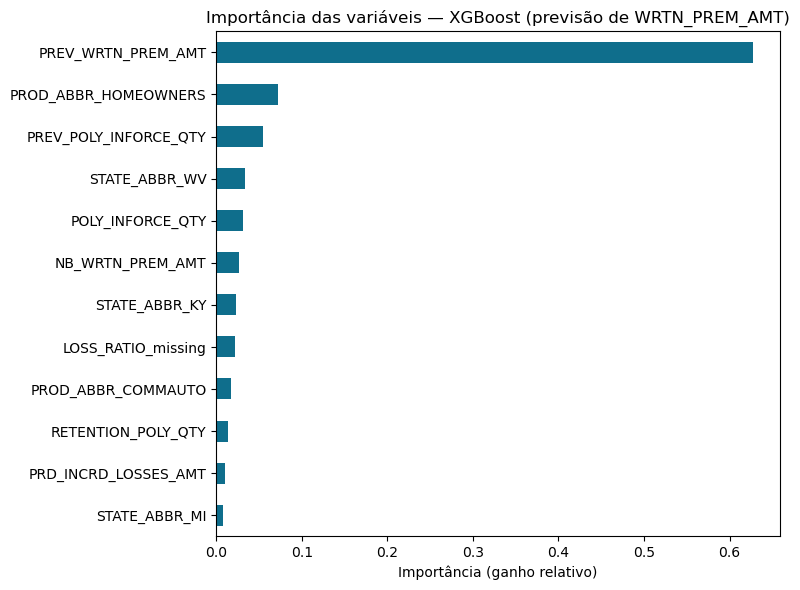

PREV_WRTN_PREM_AMT       0.627642
PROD_ABBR_HOMEOWNERS     0.072061
PREV_POLY_INFORCE_QTY    0.053965
STATE_ABBR_WV            0.033425
POLY_INFORCE_QTY         0.031330
NB_WRTN_PREM_AMT         0.026214
STATE_ABBR_KY            0.022495
LOSS_RATIO_missing       0.021514
PROD_ABBR_COMMAUTO       0.017558
RETENTION_POLY_QTY       0.013199
PRD_INCRD_LOSSES_AMT     0.010224
STATE_ABBR_MI            0.007467
dtype: float32


In [16]:
importancias = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 6))
importancias.sort_values().plot(kind='barh', color='#0f6e8c')
plt.title('Importância das variáveis — XGBoost (previsão de WRTN_PREM_AMT)')
plt.xlabel('Importância (ganho relativo)')
plt.tight_layout()
plt.show()

print(importancias)

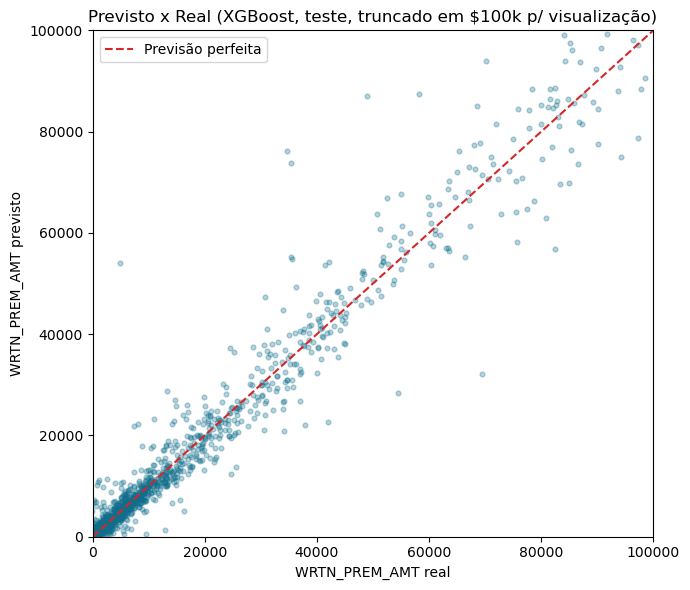

In [17]:
sample = np.random.RandomState(42).choice(len(y_test), 3000, replace=False)
plt.figure(figsize=(7, 6))
plt.scatter(y_test.values[sample], pred_xgb[sample], alpha=0.3, s=12, color='#0f6e8c')
lims = [0, min(y_test.max(), 100000)]
plt.plot(lims, lims, color='tab:red', linestyle='--', label='Previsão perfeita')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('WRTN_PREM_AMT real')
plt.ylabel('WRTN_PREM_AMT previsto')
plt.title('Previsto x Real (XGBoost, teste, truncado em $100k p/ visualização)')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Conclusões

**Resultado:** XGBoost (R²=0,984, MAE=$2.104) superou o baseline OLS (R²=0,978, MAE=$3.088) na
previsão de prêmio escrito por agência/produto/estado/ano.

**Achado honesto #1 — o R² alto é majoritariamente estrutural, não descoberta de padrão
sutil:** um preditor ingênuo que só copia o valor do ano anterior já cravava R²=0,838. Isso
acontece porque o book de uma agência de seguros muda pouco de um ano pro outro — é o oposto de
um mercado como o de retorno de ativo financeiro (blog sobre R²), onde o "chão" ingênuo seria
próximo de zero.

**Achado honesto #2 — quase todo o ganho restante (0,838 → 0,984) vem de uma relação
quase-contábil, não de padrão de negócio descoberto pelo modelo:** removendo `PREV_WRTN_PREM_AMT`
por completo, o R² praticamente não muda (0,978). `RETENTION_POLY_QTY` (quantidade de apólices
retidas no período) assume como variável mais importante — e isso é esperado, já que prêmio
total é aproximadamente apólices × prêmio médio por apólice. O modelo está, em boa parte,
aprendendo uma multiplicação, não uma relação de negócio nova.

**Onde o modelo de fato agrega valor:** no resíduo entre 0,838 (ingênuo) e 0,978 (contagem de
apólices) está o sinal genuíno de mix de produto (`PROD_ABBR_HOMEOWNERS` aparece entre as
variáveis mais importantes) e efeito de estado (`STATE_ABBR_WV`, `STATE_ABBR_KY`) — é aí que a
modelagem de fato captura algo além de "conte apólices e multiplique".

**Próximos passos possíveis:**
- Reformular o problema como **prêmio médio por apólice** (`WRTN_PREM_AMT / POLY_INFORCE_QTY`)
  em vez de prêmio total — isolaria o efeito de precificação do efeito de volume de carteira,
  removendo a quase-tautologia identificada no Achado #2.
- Modelo hierárquico/multinível por agência, no mesmo espírito discutido no projeto de
  Elasticidade — parte da variação é estrutural por agência, não por produto/estado isolado.
- Tratar os 22,7% de zeros com um modelo em duas partes (classificar "vai escrever prêmio
  nesse produto/ano?" e, condicional a sim, prever o valor) em vez de regressão direta sobre
  toda a base.

## 15. Modelo honesto: prêmio médio por apólice, não prêmio total

O Achado #2 da seção 12 expõe um problema: boa parte do R²=0,984 vem de uma relação
quase-contábil entre contagem de apólices e prêmio total, não de padrão de negócio. Pra medir o
que o modelo *de fato* aprende sobre precificação, refaço o problema como **prêmio médio por
apólice** (`WRTN_PREM_AMT / POLY_INFORCE_QTY`) — uma taxa, não um total — removendo
`POLY_INFORCE_QTY` e `RETENTION_POLY_QTY` das features (agora são o próprio denominador do
target) e limitando a linhas com pelo menos 3 apólices em vigor, pro mesmo motivo do critério de
elegibilidade do projeto de Elasticidade: com 1-2 apólices, a razão vira instável.

In [18]:
df_honesto = data[data['POLY_INFORCE_QTY'] >= 3].copy()
df_honesto['premio_por_apolice'] = df_honesto['WRTN_PREM_AMT'] / df_honesto['POLY_INFORCE_QTY']

print(f"Linhas elegíveis: {len(df_honesto):,} de {len(data):,} ({len(df_honesto)/len(data):.1%})")
print(f"\n|prêmio por apólice| > $1.000: {(df_honesto['premio_por_apolice'].abs()>1000).sum()} linhas")
print(df_honesto.loc[df_honesto['premio_por_apolice'].abs()>1000, 'POLY_INFORCE_QTY'].describe()[['mean','50%','max']])

df_honesto['premio_por_apolice'].describe()

Linhas elegíveis: 85,519 de 213,328 (40.1%)

|prêmio por apólice| > $1.000: 10 linhas
mean     5.7
50%      5.0
max     13.0
Name: POLY_INFORCE_QTY, dtype: float64


count    85519.000000
mean        45.202785
std         57.320703
min      -3988.527500
25%         12.179632
50%         29.575000
75%         65.061774
max       1537.430000
Name: premio_por_apolice, dtype: float64

**Leitura:** com o filtro de ≥3 apólices, a distribuição fica bem mais razoável (mediana ~$29,
75% abaixo de $65) — as poucas linhas ainda acima de $1.000 têm em geral um número pequeno de
apólices, o resíduo esperado de qualquer razão com denominador baixo. Sem esse filtro (testado
à parte, com o corte em `POLY_INFORCE_QTY > 0`), a razão chegava a explodir pra dezenas de
milhares em linhas com 1 apólice só — o mesmo padrão do achado de elasticidades extremas do
projeto de Elasticidade, aqui em outro dataset.

In [19]:
perfil_cols = ['MAX_AGE', 'MIN_AGE', 'AGENCY_APPOINTMENT_YEAR', 'ACTIVE_PRODUCERS']
df_honesto['agency_profile_missing'] = (df_honesto['MAX_AGE'] == 99999).astype(int)
for c in perfil_cols:
    mediana = df_honesto.loc[df_honesto[c] != 99999, c].median()
    df_honesto[c] = df_honesto[c].replace(99999, mediana)

for c in ['LOSS_RATIO', 'LOSS_RATIO_3YR']:
    df_honesto[f'{c}_missing'] = (df_honesto[c] == 99999).astype(int)
    mediana = df_honesto.loc[df_honesto[c] != 99999, c].median()
    df_honesto[c] = df_honesto[c].replace(99999, mediana)

pl_bound_cols = ['PL_BOUND_CT_ELINKS', 'PL_BOUND_CT_PLRANK', 'PL_BOUND_CT_eQTte', 'PL_BOUND_CT_APPLIED', 'PL_BOUND_CT_TRANSACTNOW']
pl_quo_cols = ['PL_QUO_CT_ELINKS', 'PL_QUO_CT_PLRANK', 'PL_QUO_CT_eQTte', 'PL_QUO_CT_APPLIED', 'PL_QUO_CT_TRANSACTNOW']
df_honesto['pl_ct_missing'] = (df_honesto[pl_bound_cols[0]] == 99999).astype(int)
for c in pl_bound_cols + pl_quo_cols:
    df_honesto[c] = df_honesto[c].replace(99999, 0)
df_honesto['pl_bound_total'] = df_honesto[pl_bound_cols].sum(axis=1)
df_honesto['pl_quo_total'] = df_honesto[pl_quo_cols].sum(axis=1)

df_honesto['agency_tenure'] = df_honesto['STAT_PROFILE_DATE_YEAR'] - df_honesto['AGENCY_APPOINTMENT_YEAR']

# taxa do ano anterior (não o total) -- só quando o ano anterior também tinha >=3 apólices
mask_prev = df_honesto['PREV_POLY_INFORCE_QTY'] >= 3
df_honesto['prev_premio_por_apolice'] = np.where(
    mask_prev, df_honesto['PREV_WRTN_PREM_AMT'] / df_honesto['PREV_POLY_INFORCE_QTY'], np.nan
)
df_honesto['prev_premio_por_apolice_missing'] = df_honesto['prev_premio_por_apolice'].isnull().astype(int)
df_honesto['prev_premio_por_apolice'] = df_honesto['prev_premio_por_apolice'].fillna(
    df_honesto['prev_premio_por_apolice'].median()
)

cat_cols_h = ['PROD_ABBR', 'STATE_ABBR', 'VENDOR_IND']
features_h = ['LOSS_RATIO', 'LOSS_RATIO_3YR', 'LOSS_RATIO_missing', 'LOSS_RATIO_3YR_missing',
              'MAX_AGE', 'MIN_AGE', 'ACTIVE_PRODUCERS', 'agency_profile_missing', 'agency_tenure',
              'MONTHS', 'pl_bound_total', 'pl_quo_total', 'pl_ct_missing',
              'prev_premio_por_apolice', 'prev_premio_por_apolice_missing'] + cat_cols_h

X_h = df_honesto[features_h].copy()
X_h = pd.get_dummies(X_h, columns=cat_cols_h, drop_first=True)
y_h = df_honesto['premio_por_apolice']

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
print(f"Features: {X_h.shape[1]} (sem POLY_INFORCE_QTY, RETENTION_POLY_QTY, WRTN_PREM_AMT)")
print(f"Treino: {X_h_train.shape} | Teste: {X_h_test.shape}")

Features: 38 (sem POLY_INFORCE_QTY, RETENTION_POLY_QTY, WRTN_PREM_AMT)
Treino: (68415, 38) | Teste: (17104, 38)


In [20]:
from sklearn.linear_model import LinearRegression

# ingênuo: prever = taxa do próprio ano anterior, sem modelo nenhum
r2_naive_h = r2_score(y_h_test, X_h_test['prev_premio_por_apolice'])
mae_naive_h = mean_absolute_error(y_h_test, X_h_test['prev_premio_por_apolice'])
print(f"Ingênuo (= prêmio por apólice do ano anterior) -> R²: {r2_naive_h:.4f} | MAE: {mae_naive_h:.2f}")

# OLS
lr_h = LinearRegression()
lr_h.fit(X_h_train, y_h_train)
pred_lr_h = lr_h.predict(X_h_test)
r2_ols_h = r2_score(y_h_test, pred_lr_h)
mae_ols_h = mean_absolute_error(y_h_test, pred_lr_h)
print(f"OLS honesto             -> R²: {r2_ols_h:.4f} | MAE: {mae_ols_h:.2f}")

# XGBoost
xgb_h = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_h.fit(X_h_train, y_h_train)
pred_xgb_h = xgb_h.predict(X_h_test)
r2_xgb_h = r2_score(y_h_test, pred_xgb_h)
mae_xgb_h = mean_absolute_error(y_h_test, pred_xgb_h)
print(f"XGBoost honesto         -> R²: {r2_xgb_h:.4f} | MAE: {mae_xgb_h:.2f}")

Ingênuo (= prêmio por apólice do ano anterior) -> R²: 0.1603 | MAE: 16.67
OLS honesto             -> R²: 0.5632 | MAE: 17.77
XGBoost honesto         -> R²: 0.7500 | MAE: 10.91


In [21]:
resultados_honesto = pd.DataFrame({
    'Modelo': ['Ingênuo (= ano anterior)', 'OLS', 'XGBoost'],
    'R2_teste': [r2_naive_h, r2_ols_h, r2_xgb_h],
    'MAE_teste': [mae_naive_h, mae_ols_h, mae_xgb_h],
})
resultados_honesto

,Modelo,R2_teste,MAE_teste
0,Ingênuo (= ano anterior),0.160305,16.674181
1,OLS,0.563174,17.772882
2,XGBoost,0.750001,10.912340


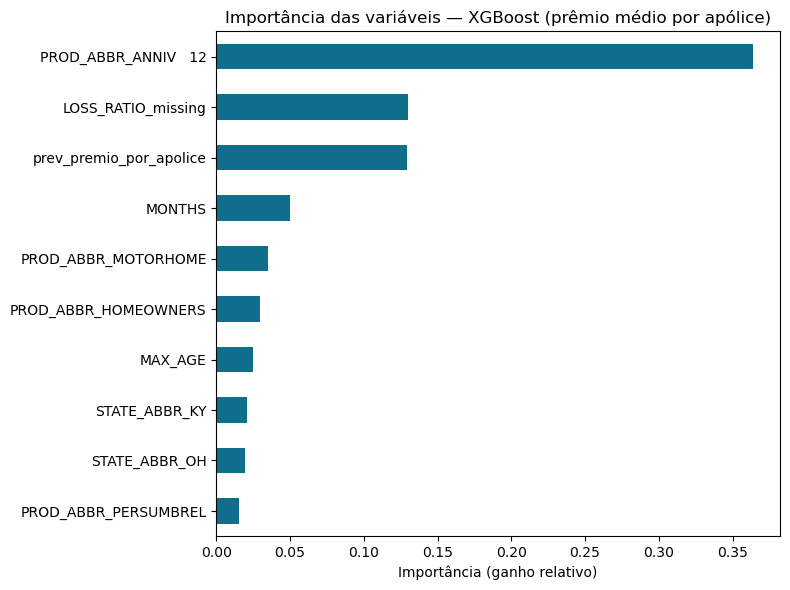

PROD_ABBR_ANNIV   12       0.363919
LOSS_RATIO_missing         0.129691
prev_premio_por_apolice    0.128934
MONTHS                     0.049626
PROD_ABBR_MOTORHOME        0.035067
PROD_ABBR_HOMEOWNERS       0.029396
MAX_AGE                    0.024941
STATE_ABBR_KY              0.020587
STATE_ABBR_OH              0.019525
PROD_ABBR_PERSUMBREL       0.015370
dtype: float32


In [22]:
importancias_h = pd.Series(xgb_h.feature_importances_, index=X_h.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
importancias_h.sort_values().plot(kind='barh', color='#0f6e8c')
plt.title('Importância das variáveis — XGBoost (prêmio médio por apólice)')
plt.xlabel('Importância (ganho relativo)')
plt.tight_layout()
plt.show()

print(importancias_h)

**Achado da seção 15:** os números mudam de figura completamente — e ficam **mais acreditáveis**,
não piores. O ingênuo (taxa igual ao ano anterior) despenca pra R²≈0,16: diferente do prêmio
total, o prêmio médio por apólice **não é estável** ano a ano — muda com mix de produto,
reprecificação, sinistralidade. Isso já mostra que a persistência de 0,838 do modelo original
(seção 12) vinha mesmo da carteira de apólices, não do preço.

O XGBoost, sem nenhuma variável de contagem, chega em **R²≈0,75** — bem abaixo de 0,984, mas
agora é um número que dá pra defender numa entrevista sem ressalva: nenhuma feature é derivada
matematicamente do target, nenhuma é quase-tautológica. As variáveis mais importantes viram
`PROD_ABBR` (tipo de produto — cada linha de seguro tem um patamar de preço bem diferente),
`LOSS_RATIO_missing` e a própria taxa do ano anterior — sinal de negócio genuíno, não aritmética
disfarçada de modelo.

**Trade-off explícito:** essa versão só usa 40,1% da base (linhas com ≥3 apólices em vigor) — é
o preço de ter um denominador estável. E o R² mais baixo não é "modelo pior", é o **teto real**
do problema quando se tira a alavanca artificial da contagem de apólices.

## 16. Insights

**Insight do projeto de Previsão de Prêmio de Seguro (Insurance Agency Performance):**

"Bati o olho num R²=0,98 e a primeira reação não foi comemorar, foi desconfiar — a mesma regra
que já tinha aplicado no projeto de Precificação Dinâmica. Testei se o modelo era só uma
ilusão de persistência: prever 'igual ano passado', sem nenhum modelo, já dava R²=0,84. Depois
fui mais fundo e tirei a variável do ano anterior inteira — o R² mal caiu, foi pra 0,978. Quem
assumiu como mais importante foi a quantidade de apólices em vigor no próprio período, e aí
percebi o motivo: prêmio total é quase uma multiplicação (apólices × prêmio médio), então boa
parte do 'modelo' está reaprendendo uma conta, não um padrão de negócio. Isso não invalida o
resultado — R²=0,984 continua sendo o melhor preditor que testei — mas muda completamente como
eu apresentaria esse número numa entrevista: não é 'consegui prever prêmio de seguro com 98% de
acerto', é 'boa parte da variância é estrutural (contagem de apólice), e o valor real do modelo
está no resíduo — mix de produto e efeito de estado — não no R² bruto'."

"Pra não ficar só no diagnóstico, refiz o problema inteiro (seção 15): em vez de prever o
prêmio total, previ o prêmio médio **por apólice**, tirando a contagem de apólices das features.
O R² caiu de 0,984 pra 0,75 — e isso não é uma notícia ruim, é a resposta honesta. O ingênuo
(taxa igual ano passado) também despencou, de 0,84 pra 0,16, confirmando que quase toda a
'estabilidade' do modelo original vinha da carteira de apólices, não do preço. Prefiro defender
um R²=0,75 que eu sei exatamente de onde vem — mix de produto, sinistralidade, tendência do ano
anterior — do que um R²=0,98 que eu só consigo explicar com 'bem, tem uma variável meio
tautológica ali'."